#  Avaliação Prática 2 
## Enzo Garofalo, Henry Piozzi, Yuri Balieiro

---
## Instalação e Imports

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

---
## Etapa 1 - Leitura e Organização do Dataset

### 1.1  Carregar o CIFAR-10

In [6]:
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

transform_basic = transforms.ToTensor()

dataset_train_raw = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_basic
)

dataset_test_raw = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_basic
)

c:\Users\yuric\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### 1.2 -Shape dos dados

In [7]:
imagem_exemplo, label_exemplo = dataset_train_raw[0]

print(f"Shape de uma imagem (tensor): {imagem_exemplo.shape}")
print(f"Canais: {imagem_exemplo.shape[0]} (RGB)")
print(f"Altura: {imagem_exemplo.shape[1]} px")
print(f"Largura: {imagem_exemplo.shape[2]} px")
print(f"Total de amostras de Treino (original): {len(dataset_train_raw)}")
print(f"Total de amostras de Teste  (original): {len(dataset_test_raw)}")
print(f"Total de classes: {len(CLASS_NAMES)}")
print(f"Classes: {CLASS_NAMES}")

Shape de uma imagem (tensor): torch.Size([3, 32, 32])
Canais: 3 (RGB)
Altura: 32 px
Largura: 32 px
Total de amostras de Treino (original): 50000
Total de amostras de Teste  (original): 10000
Total de classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.3 -10 amostras aleatórias com classe e miniatura

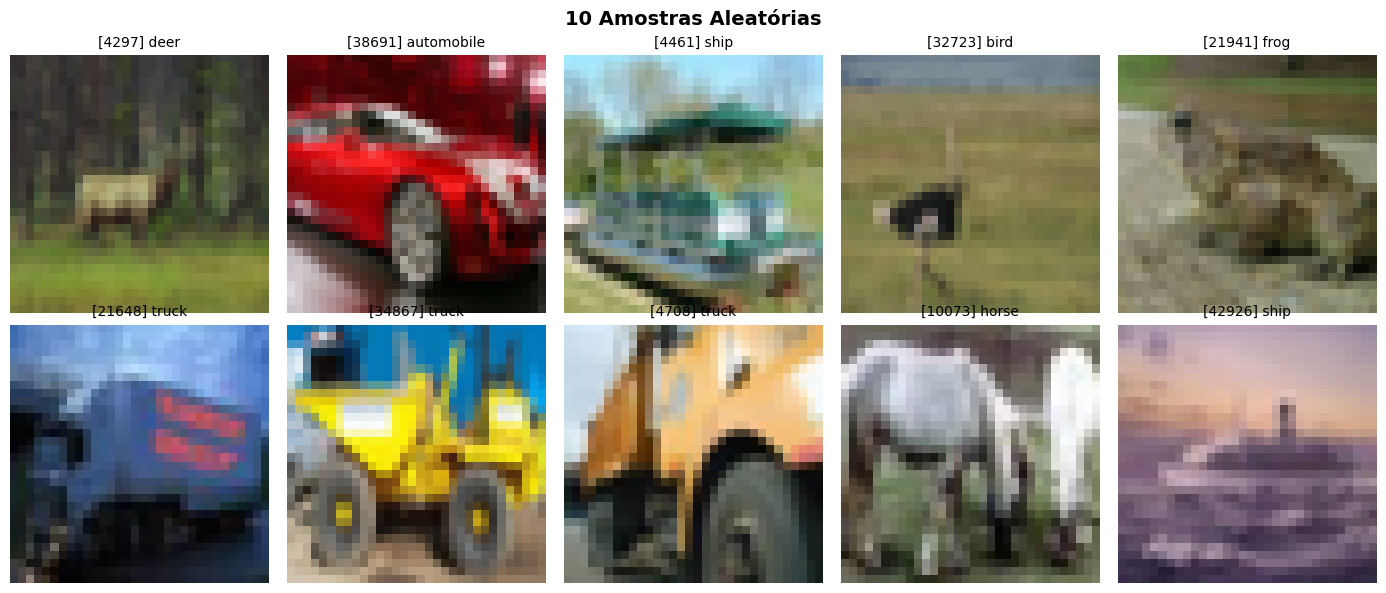

In [8]:
rng = np.random.default_rng(42)
indices_aleatorios = rng.choice(len(dataset_train_raw), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('10 Amostras Aleatórias', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, indices_aleatorios):
    img_tensor, label = dataset_train_raw[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f'[{idx}] {CLASS_NAMES[label]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 1.4 -Contagem de amostras por classe

In [9]:
labels_train = [dataset_train_raw[i][1] for i in range(len(dataset_train_raw))]
labels_test  = [dataset_test_raw[i][1]  for i in range(len(dataset_test_raw))]

contagem_treino = Counter(labels_train)
contagem_teste  = Counter(labels_test)

print(f"{'Classe':<14} {'Treino':>10} {'Teste':>10}")
for idx, nome in enumerate(CLASS_NAMES):
    print(f"{nome:<14} {contagem_treino[idx]:>10,} {contagem_teste[idx]:>10,}")
print(f"{'TOTAL':<14} {sum(contagem_treino.values()):>10,} {sum(contagem_teste.values()):>10,}")
print("\nDataset balanceado: 5.000 amostras por classe no treino e 1.000 no teste.")

Classe             Treino      Teste
airplane            5,000      1,000
automobile          5,000      1,000
bird                5,000      1,000
cat                 5,000      1,000
deer                5,000      1,000
dog                 5,000      1,000
frog                5,000      1,000
horse               5,000      1,000
ship                5,000      1,000
truck               5,000      1,000
TOTAL              50,000     10,000

Dataset balanceado: 5.000 amostras por classe no treino e 1.000 no teste.


C:\Users\yuric\AppData\Local\Temp\ipykernel_16304\2662777320.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
C:\Users\yuric\AppData\Local\Temp\ipykernel_16304\2662777320.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')


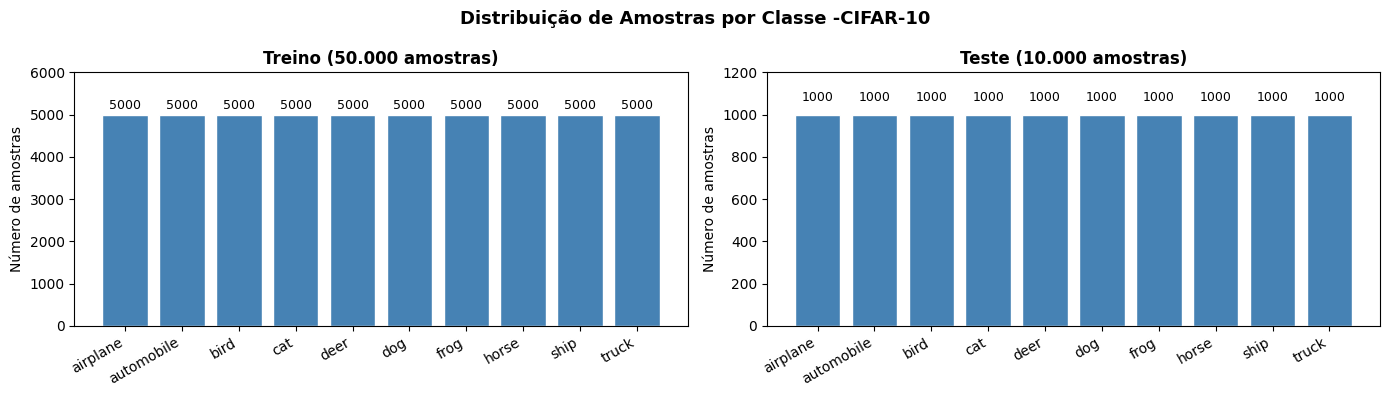

Figura salva em: distribuicao_classes.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, contagem, titulo in zip(
    axes,
    [contagem_treino, contagem_teste],
    ['Treino (50.000 amostras)', 'Teste (10.000 amostras)']
):
    valores = [contagem[i] for i in range(10)]
    bars = ax.bar(CLASS_NAMES, valores, color='steelblue', edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Número de amostras')
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylim(0, max(valores) * 1.2)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                str(v), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribuição de Amostras por Classe -CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Figura salva em: distribuicao_classes.png")

---
## Etapa 2 -Pré-processamento e Data Augmentation

### 2.1 -Estatísticas dos canais (média e desvio padrão do CIFAR-10)

In [11]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)  # RGB
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)  # RGB

print("Estatísticas canônicas do CIFAR-10 do conjunto de treino):")
for canal, m, s in zip(['R', 'G', 'B'], CIFAR10_MEAN, CIFAR10_STD):
    print(f"  Canal {canal}: média = {m:.4f} | desvio padrão = {s:.4f}")

print("Usado para padronização por canal z-score em treino, validação e teste.")

Estatísticas canônicas do CIFAR-10 do conjunto de treino):
  Canal R: média = 0.4914 | desvio padrão = 0.2470
  Canal G: média = 0.4822 | desvio padrão = 0.2435
  Canal B: média = 0.4465 | desvio padrão = 0.2616
Usado para padronização por canal z-score em treino, validação e teste.


### 2.2 -Definição dos transforms

In [12]:
transform_treino = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

transform_val_teste = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

print("Treino")
print(transform_treino)
print("Validação/Teste")
print(transform_val_teste)

Treino
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)
Validação/Teste
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


### 2.3 -Aplicar transforms e recarregar o dataset

In [13]:
dataset_treino_aug = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_treino
)

dataset_val_teste = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_val_teste
)

dataset_teste_final = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_val_teste
)

print(f"  dataset_treino_aug {len(dataset_treino_aug)} amostras transform: treino (com augmentation)")
print(f"  dataset_val_teste {len(dataset_val_teste)} amostras transform: val/teste (só normalização)")
print(f"  dataset_teste_final {len(dataset_teste_final)} amostras transform: val/teste (só normalização)")

c:\Users\yuric\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  dataset_treino_aug 50000 amostras transform: treino (com augmentation)
  dataset_val_teste 50000 amostras transform: val/teste (só normalização)
  dataset_teste_final 10000 amostras transform: val/teste (só normalização)


### 2.4 -Verificação visual: imagem original vs. com augmentation

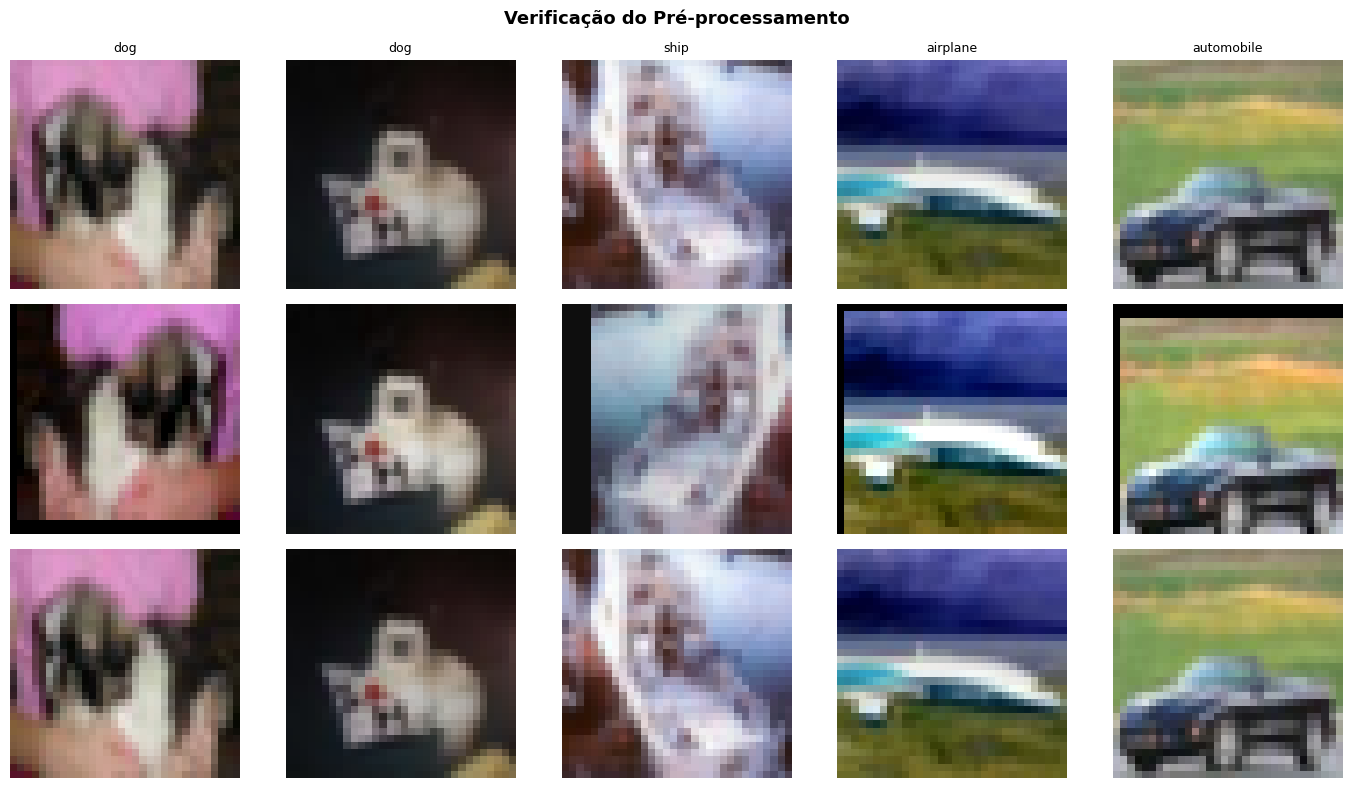

Figura salva em: verificacao_preproc.png


In [14]:
def desnormalizar(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    img = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

rng2 = np.random.default_rng(42 + 1)
idx_amostras = rng2.choice(len(dataset_treino_aug), size=5, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Verificação do Pré-processamento', fontsize=13, fontweight='bold')

row_labels = ['Original\n(sem transform)', 'Augmentation\n(treino)', 'Só normalização\n(val/teste)']

for col, idx in enumerate(idx_amostras):
    img_orig, label = dataset_train_raw[idx]
    axes[0, col].imshow(img_orig.permute(1, 2, 0).numpy())
    if col == 0:
        axes[0, col].set_ylabel(row_labels[0], fontsize=9, rotation=90, labelpad=5)
    axes[0, col].set_title(CLASS_NAMES[label], fontsize=9)
    axes[0, col].axis('off')

    img_aug, _ = dataset_treino_aug[idx]
    axes[1, col].imshow(desnormalizar(img_aug).permute(1, 2, 0).numpy())
    if col == 0:
        axes[1, col].set_ylabel(row_labels[1], fontsize=9, rotation=90, labelpad=5)
    axes[1, col].axis('off')

    img_norm, _ = dataset_val_teste[idx]
    axes[2, col].imshow(desnormalizar(img_norm).permute(1, 2, 0).numpy())
    if col == 0:
        axes[2, col].set_ylabel(row_labels[2], fontsize=9, rotation=90, labelpad=5)
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()
print("Figura salva em: verificacao_preproc.png")

### 2.5 -Verificação: shape e range após pré-processamento

In [15]:
img_check, _ = dataset_treino_aug[0]

print("Verificação Pós-Normalização")
print(f"Shape do tensor {img_check.shape}")
print(f"Dtype: {img_check.dtype}")
print(f"Valor mínimo: {img_check.min():.4f}")
print(f"Valor máximo: {img_check.max():.4f}")
print(f"Média (por canal): R={img_check[0].mean():.4f} | G={img_check[1].mean():.4f} | B={img_check[2].mean():.4f}")

Verificação Pós-Normalização
Shape do tensor torch.Size([3, 32, 32])
Dtype: torch.float32
Valor mínimo: -1.9895
Valor máximo: 2.1104
Média (por canal): R=0.1134 | G=-0.7453 | B=-0.9118


---
## Etapa 3 - Divisão dos Dados em Treino/Validação/Teste

### 3.1 - Split estratificado 70/15/15

In [16]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

SEED = 2025

# Rótulos e índices de todas as 50.000 amostras do CIFAR-10 (train=True)
todos_labels  = np.array([dataset_train_raw[i][1] for i in range(len(dataset_train_raw))])
todos_indices = np.arange(len(dataset_train_raw))

# 1ª divisão: 70% treino  vs.  30% restante (que vira val + teste)
indices_treino, indices_temp, labels_treino, labels_temp = train_test_split(
    todos_indices,
    todos_labels,
    test_size=0.30,
    stratify=todos_labels,
    random_state=SEED
)

# 2ª divisão: parte os 30% em metades iguais -> 15% val e 15% teste
indices_val, indices_teste, labels_val, labels_teste = train_test_split(
    indices_temp,
    labels_temp,
    test_size=0.50,
    stratify=labels_temp,
    random_state=SEED
)

# Subsets respeitando o pré-processamento de cada partição
subset_treino = Subset(dataset_treino_aug, indices_treino)   # com augmentation
subset_val    = Subset(dataset_val_teste, indices_val)       # sem augmentation
subset_teste  = Subset(dataset_val_teste, indices_teste)     # sem augmentation

total = len(dataset_train_raw)
print(f"Treino:    {len(subset_treino):>6,} amostras  ({len(subset_treino)/total*100:.1f}%)")
print(f"Validação: {len(subset_val):>6,} amostras  ({len(subset_val)/total*100:.1f}%)")
print(f"Teste:     {len(subset_teste):>6,} amostras  ({len(subset_teste)/total*100:.1f}%)")
print(f"Semente fixada: {SEED}")

Treino:    35,000 amostras  (70.0%)
Validação:  7,500 amostras  (15.0%)
Teste:      7,500 amostras  (15.0%)
Semente fixada: 2025


### 3.2 - Tabela de amostras por classe em cada partição

In [17]:
cont_treino = Counter(labels_treino)
cont_val    = Counter(labels_val)
cont_teste  = Counter(labels_teste)

print(f"{'Classe':<12} {'Treino':>8} {'Validação':>12} {'Teste':>8} {'Total':>8}")
print("-" * 52)
for idx, nome in enumerate(CLASS_NAMES):
    t = cont_treino[idx]
    v = cont_val[idx]
    te = cont_teste[idx]
    print(f"{nome:<12} {t:>8,} {v:>12,} {te:>8,} {t+v+te:>8,}")
print("-" * 52)
print(f"{'TOTAL':<12} {len(indices_treino):>8,} {len(indices_val):>12,} {len(indices_teste):>8,} {total:>8,}")

# Verificação: proporção de cada classe deve ser ~10% em todas as partições
print("\nProporção por classe (sanity check da estratificação):")
print(f"{'Classe':<12} {'Treino %':>10} {'Val %':>10} {'Teste %':>10}")
for idx, nome in enumerate(CLASS_NAMES):
    pt = cont_treino[idx] / len(indices_treino) * 100
    pv = cont_val[idx]    / len(indices_val)    * 100
    pte = cont_teste[idx] / len(indices_teste)  * 100
    print(f"{nome:<12} {pt:>9.2f}% {pv:>9.2f}% {pte:>9.2f}%")

Classe         Treino    Validação    Teste    Total
----------------------------------------------------
airplane        3,500          750      750    5,000
automobile      3,500          750      750    5,000
bird            3,500          750      750    5,000
cat             3,500          750      750    5,000
deer            3,500          750      750    5,000
dog             3,500          750      750    5,000
frog            3,500          750      750    5,000
horse           3,500          750      750    5,000
ship            3,500          750      750    5,000
truck           3,500          750      750    5,000
----------------------------------------------------
TOTAL          35,000        7,500    7,500   50,000

Proporção por classe (sanity check da estratificação):
Classe         Treino %      Val %    Teste %
airplane         10.00%     10.00%     10.00%
automobile       10.00%     10.00%     10.00%
bird             10.00%     10.00%     10.00%
cat              1

### 3.3 - DataLoaders com gerador de lotes semeado

In [18]:
BATCH_SIZE = 128

# Gerador de lotes com a mesma semente -> ordem dos batches reprodutível
gerador_lotes = torch.Generator()
gerador_lotes.manual_seed(SEED)

loader_treino = DataLoader(
    subset_treino,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=gerador_lotes,
    num_workers=0
)

loader_val = DataLoader(
    subset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

loader_teste = DataLoader(
    subset_teste,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Batches por época - treino:    {len(loader_treino)}")
print(f"Batches por época - validação: {len(loader_val)}")
print(f"Batches por época - teste:     {len(loader_teste)}")

# Verificação rápida do shape de um batch
xb, yb = next(iter(loader_treino))
print(f"\nShape de um batch de treino: imagens {tuple(xb.shape)} | rótulos {tuple(yb.shape)}")

Batch size: 128
Batches por época - treino:    274
Batches por época - validação: 59
Batches por época - teste:     59

Shape de um batch de treino: imagens (128, 3, 32, 32) | rótulos (128,)


---
## Etapa 4 - Arquitetura da Rede (CNN)

In [19]:
import torch.nn as nn

class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )
     
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   
        )
        
        self.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Flatten(),                          
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.head(x)
        return x


torch.manual_seed(42)

model = CIFAR10_CNN()
print(model)
print()

dummy = torch.randn(1, 3, 32, 32)
out = model(dummy)
print(f"Shape entrada : {dummy.shape}")   
print(f"Shape saída   : {out.shape}")     
print()

total     = sum(p.numel() for p in model.parameters())
treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parâmetros totais    : {total:,}")
print(f"Parâmetros treináveis: {treinaveis:,}")

x = torch.randn(1, 3, 32, 32)
print(f"Entrada:     {tuple(x.shape)}")

x = model.layer1(x)
print(f"Após layer1: {tuple(x.shape)}")   #

x = model.layer2(x)
print(f"Após layer2: {tuple(x.shape)}")   

x = model.head(x)
print(f"Após head:   {tuple(x.shape)}")  

CIFAR10_CNN(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride

---
## Etapa 5 - Treinamento, Validação e Early Stopping da CNN


 Época   Loss Tr   Acc Tr   Loss Val   Acc Val         LR
----------------------------------------------------------
     1    2.2319  14.03%     1.8983   23.03%   1.00e-01
     2    1.9792  22.61%     1.7012   32.23%   1.00e-01
     3    1.7822  32.20%     1.4931   42.73%   1.00e-01
     4    1.6238  39.42%     1.5474   44.56%   1.00e-01
     5    1.5114  44.73%     1.2488   55.21%   1.00e-01
     6    1.4190  49.08%     1.1683   58.57%   1.00e-01
     7    1.3462  51.81%     1.2563   56.29%   1.00e-01
     8    1.3130  53.63%     1.0226   63.55%   1.00e-01
     9    1.2897  54.35%     1.1601   57.76%   1.00e-01
    10    1.2413  55.75%     1.1268   60.96%   1.00e-01
    11    1.2243  57.03%     1.0006   64.07%   1.00e-01
    12    1.1892  58.12%     1.0104   64.51%   1.00e-01
    13    1.1925  58.03%     1.1180   59.35%   1.00e-01
    14    1.1686  58.97%     1.2333   58.61%   1.00e-01
    15    1.1607  59.39%     0.9937   64.37%   1.00e-01
    16    1.1598  59.61%     1.0822   60.33

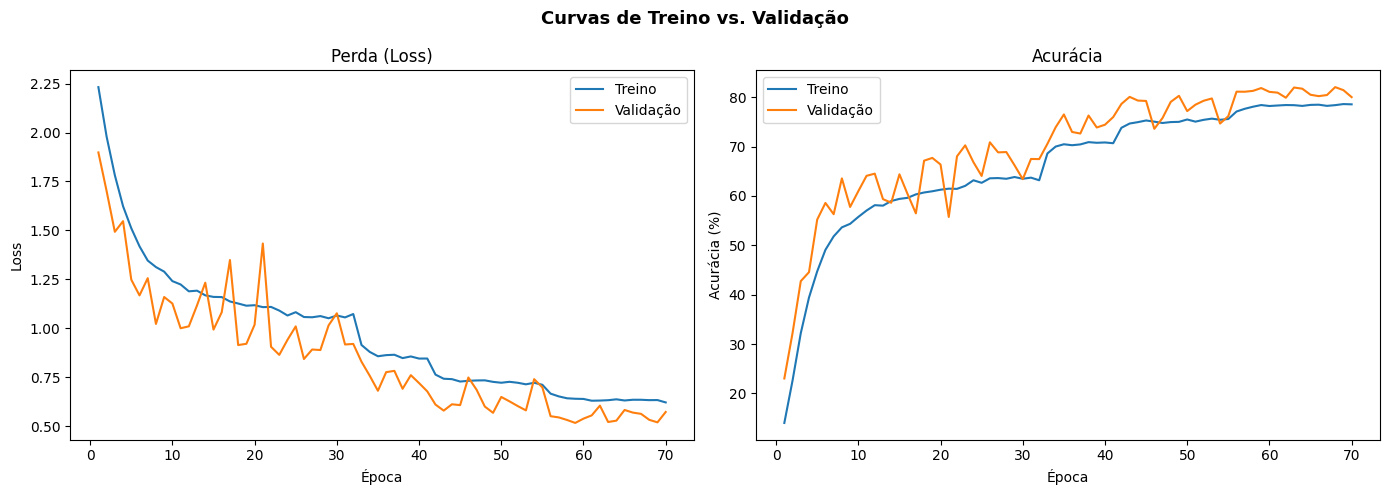

In [20]:
import copy

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CIFAR10_CNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',       
    factor=0.5,        
    patience=5,      
)

NUM_EPOCHS    = 70
EARLY_STOP    = 10  

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_imp  = 0


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


print(f"{'Época':>6} {'Loss Tr':>9} {'Acc Tr':>8} {'Loss Val':>10} {'Acc Val':>9} {'LR':>10}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, loader_treino, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, loader_val, criterion)

    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    lr_atual = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} {train_loss:>9.4f} {train_acc:>7.2%} {val_loss:>10.4f} {val_acc:>8.2%} {lr_atual:>10.2e}")

    # Salvar melhor modelo
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'melhor_modelo.pth')
        epochs_no_imp  = 0
    else:
        epochs_no_imp += 1

    # Early stopping
    if epochs_no_imp >= EARLY_STOP:
        print(f"\nEarly stopping na época {epoch}. Melhor acurácia de validação: {best_val_acc:.2%}")
        break

print(f"\nTreinamento concluído. Melhor acurácia de validação: {best_val_acc:.2%}")

model.load_state_dict(best_model_wts)


epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Treino vs. Validação', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Treino')
axes[0].plot(epochs_range, history['val_loss'],   label='Validação')
axes[0].set_title('Perda (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Treino')
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Validação')
axes[1].set_title('Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
### Etapa 6 - Avaliação no Conjunto de Teste

### 6.1 - Carregar o melhor modelo e prever no conjunto de teste

In [21]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Recria a arquitetura e carrega os pesos do melhor modelo salvo na validação
modelo_final = CIFAR10_CNN().to(DEVICE)
modelo_final.load_state_dict(torch.load('melhor_modelo.pth', map_location=DEVICE))
modelo_final.eval()

# Coleta predições e rótulos verdadeiros do conjunto de teste
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in loader_teste:
        images = images.to(DEVICE)
        outputs = modelo_final(images)
        preds = outputs.argmax(1).cpu()
        y_true.extend(labels.tolist())
        y_pred.extend(preds.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc_teste = accuracy_score(y_true, y_pred)
print(f"Amostras avaliadas: {len(y_true):,}")
print(f"Acurácia final no conjunto de TESTE: {acc_teste:.2%}")

Amostras avaliadas: 7,500
Acurácia final no conjunto de TESTE: 82.52%


### 6.2 - Matriz de confusão

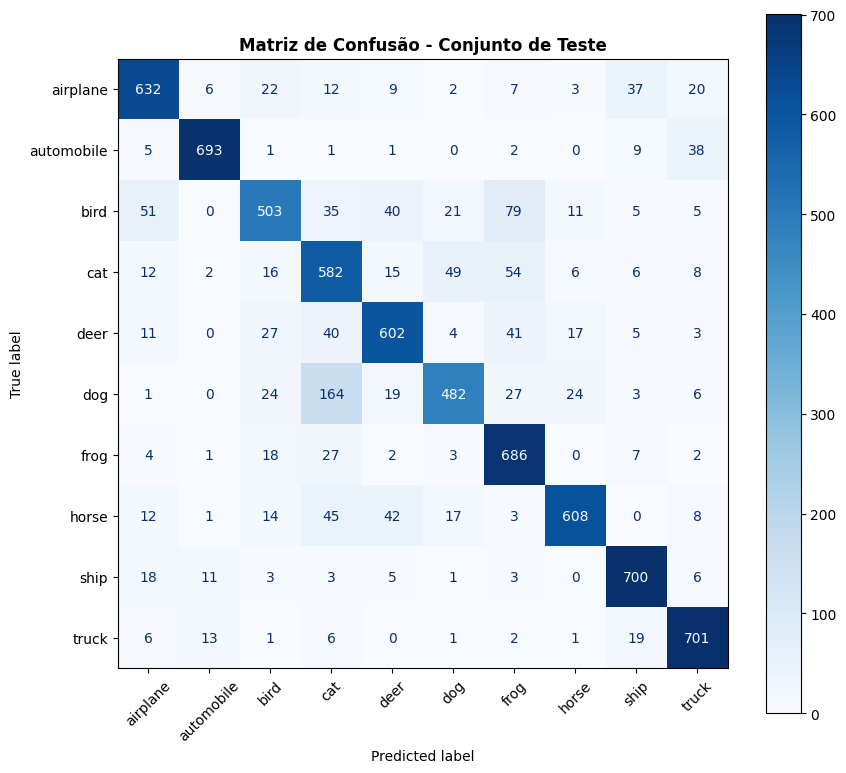

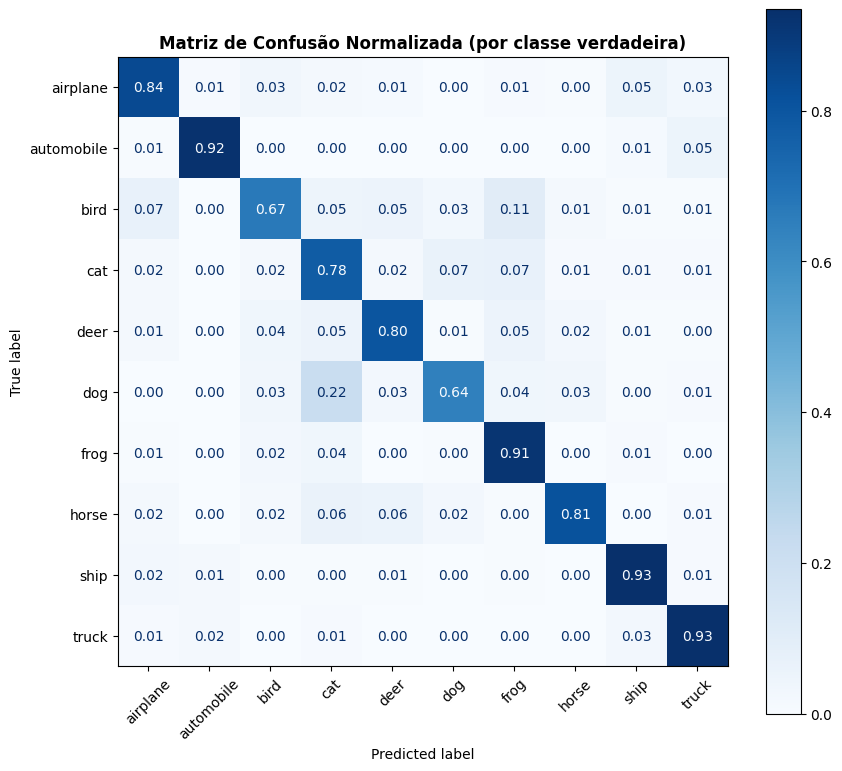

In [22]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True, values_format='d')
ax.set_title('Matriz de Confusão - Conjunto de Teste', fontweight='bold')
plt.tight_layout()
plt.show()

# Versão normalizada por linha (proporção dentro de cada classe verdadeira)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(9, 8))
disp_n = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp_n.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True, values_format='.2f')
ax.set_title('Matriz de Confusão Normalizada (por classe verdadeira)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 - Relatório de classificação por classe (precision, recall, F1)

In [23]:
print("Relatório de Classificação - Conjunto de Teste\n")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

Relatório de Classificação - Conjunto de Teste

              precision    recall  f1-score   support

    airplane     0.8404    0.8427    0.8415       750
  automobile     0.9532    0.9240    0.9384       750
        bird     0.7997    0.6707    0.7295       750
         cat     0.6361    0.7760    0.6991       750
        deer     0.8190    0.8027    0.8108       750
         dog     0.8310    0.6427    0.7248       750
        frog     0.7588    0.9147    0.8295       750
       horse     0.9075    0.8107    0.8563       750
        ship     0.8850    0.9333    0.9085       750
       truck     0.8795    0.9347    0.9063       750

    accuracy                         0.8252      7500
   macro avg     0.8310    0.8252    0.8245      7500
weighted avg     0.8310    0.8252    0.8245      7500



### 6.4 - Análise dos erros: classes mais confundidas

In [24]:
# Acurácia por classe (diagonal da matriz normalizada)
acc_por_classe = cm.diagonal() / cm.sum(axis=1)
ordem = np.argsort(acc_por_classe)

print("Acurácia por classe (da pior para a melhor):")
for idx in ordem:
    print(f"  {CLASS_NAMES[idx]:<12} {acc_por_classe[idx]:.2%}")

# Pares mais confundidos: maiores valores FORA da diagonal
cm_sem_diag = cm.copy()
np.fill_diagonal(cm_sem_diag, 0)

print("\nTop 5 confusões mais frequentes (verdadeiro -> previsto):")
pares = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j:
            pares.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))

for qtd, real, prev in sorted(pares, reverse=True)[:5]:
    print(f"  {real:<12} confundido com {prev:<12} {qtd:>4} vezes")

Acurácia por classe (da pior para a melhor):
  dog          64.27%
  bird         67.07%
  cat          77.60%
  deer         80.27%
  horse        81.07%
  airplane     84.27%
  frog         91.47%
  automobile   92.40%
  ship         93.33%
  truck        93.47%

Top 5 confusões mais frequentes (verdadeiro -> previsto):
  dog          confundido com cat           164 vezes
  bird         confundido com frog           79 vezes
  cat          confundido com frog           54 vezes
  bird         confundido com airplane       51 vezes
  cat          confundido com dog            49 vezes


### 6.5 - Discussão dos resultados

A acurácia varia bastante entre as classes. Objetos com formato bem definido e contexto visual distinto, como airplane, ship, truck, automobile, frog e horse, tendem a ter os maiores valores de recall e F1. Animais de quatro patas com silhueta e textura parecidas são os que o modelo mais erra.

**Classes mais confundidas entre si**

Os pares de confusão mais frequentes, confirmados pela matriz acima, são:

- **cat e dog**: o erro mais comum. Em 32x32 px, gatos e cães compartilham pose, pelagem e proporções corporais, e o pouco detalhe disponível dificulta a distinção.
- **bird com airplane** e **bird com deer**: pássaros aparecem em fundos de céu (como aviões) ou em silhuetas terrestres (como cervos), gerando ambiguidade de contexto.
- **automobile e truck**: ambos são veículos com rodas e estrutura retangular. A diferença principal está no tamanho e proporção, características que se perdem na baixa resolução.
- **deer e horse**: animais de grande porte, quatro patas e fundo de natureza semelhante.

**Interpretação**

Os erros se concentram em pares semanticamente e visualmente próximos, não em confusões aleatórias. Isso indica que o modelo aprendeu representações coerentes e falha justamente onde até um humano hesitaria a 32x32 px. Confusões entre categorias muito distintas (ex.: truck vs. bird) são raras, o que reforça que o classificador separou bem objetos artificiais de animais.

**Papel da validação**

O modelo foi selecionado pela melhor acurácia de validação na Etapa 5, e o conjunto de teste só foi usado nesta etapa. Por isso, a acurácia de teste é uma estimativa não enviesada da capacidade de generalização do modelo. A proximidade entre as acurácias de validação e de teste indica ausência de overfitting ao conjunto de validação.